# LOAN DEFAULT RISK PREDICTION

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv("../data/raw/train.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [2]:
df.shape

(614, 13)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [4]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [5]:
df.describe(include="all")

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,601,611,599,614,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614
unique,614,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP001002,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,NaN


In [6]:
df.isna().sum()[df.isna().sum()>0]

Gender              13
Married              3
Dependents          15
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
dtype: int64

## INITIAL OBSERVATIONS

- Number of rows: 614
- Number of columns:13
- Target variable:
- Numerical columns:5
- Categorical columns:8
- Columns with missing values: Gender, Married, Dependents, Self_Employed, Loan_Amount_Term, LoanAmount, Credit_History

## APPLICANT INCOME

- The distribution is positively (right) skewed.
- The standard deviation (6109.04) is high, indicating considerable variability in applicant incomes.
- The boxplot shows several high-income observations beyond the upper whisker.
- These observations are not necessarily errors; they may represent genuinely high-income applicants.
- No missing values are present.

count      614.000000
mean      5403.459283
std       6109.041673
min        150.000000
25%       2877.500000
50%       3812.500000
75%       5795.000000
max      81000.000000
Name: ApplicantIncome, dtype: float64


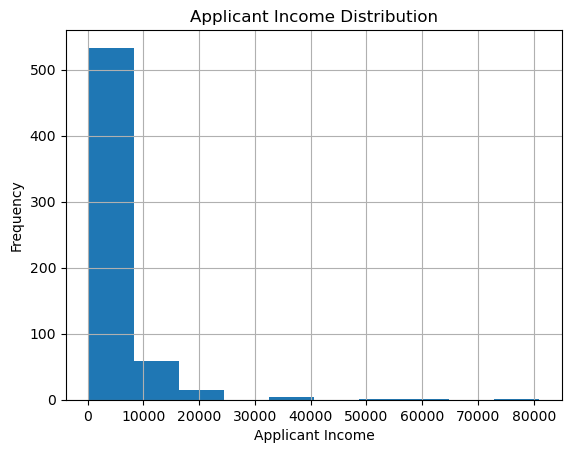

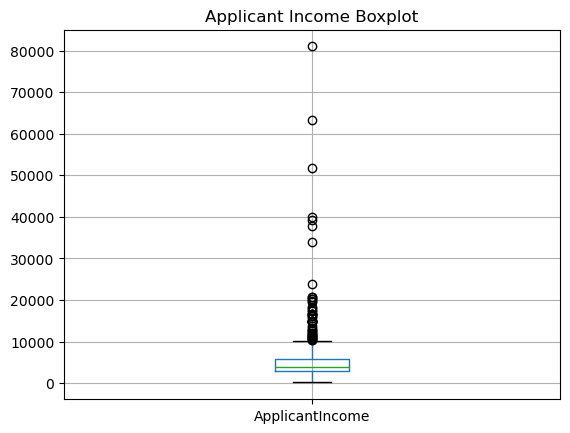

In [7]:
print(df["ApplicantIncome"].describe())
df["ApplicantIncome"].hist()

plt.title("Applicant Income Distribution")
plt.xlabel("Applicant Income")
plt.ylabel("Frequency")

plt.show()

df.boxplot(column="ApplicantIncome")

plt.title("Applicant Income Boxplot")

plt.show()

## CO-APPLICANT INCOME

- The distribution is highly right-skewed.
- The standard deviation is high (2926.25), indicating substantial variability.
- Many applicants have a coapplicant income of 0, suggesting they applied without a coapplicant.
- The boxplot shows several high-income observations beyond the upper whisker.
- No missing values are present.

count      614.000000
mean      1621.245798
std       2926.248369
min          0.000000
25%          0.000000
50%       1188.500000
75%       2297.250000
max      41667.000000
Name: CoapplicantIncome, dtype: float64


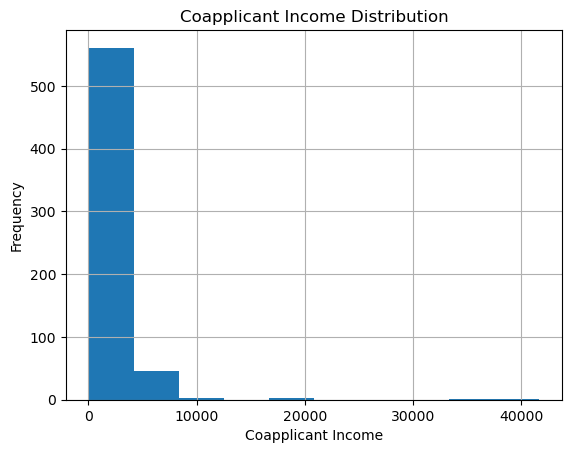

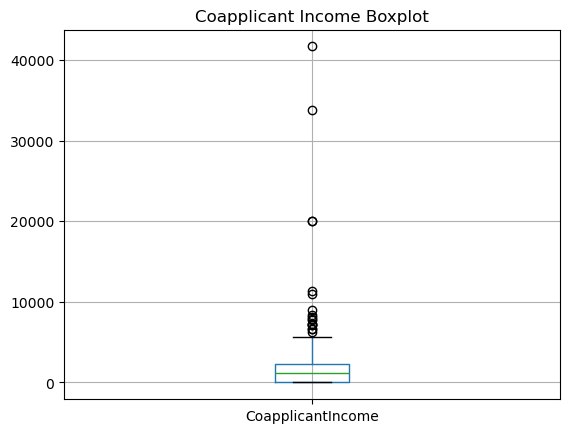

Missing Values: 0


In [8]:
print(df["CoapplicantIncome"].describe())

df["CoapplicantIncome"].hist()
plt.title("Coapplicant Income Distribution")
plt.xlabel("Coapplicant Income")
plt.ylabel("Frequency")
plt.show()

df.boxplot(column="CoapplicantIncome")
plt.title("Coapplicant Income Boxplot")
plt.show()

print("Missing Values:", df["CoapplicantIncome"].isna().sum())

## LOAN AMOUNT
- There are 22 missing values
- The standard deviation is moderate with a value of 85.587325
- The boxplot identifies potential outliers according to the IQR rule. These observations may represent legitimately large loans rather than data errors.
- The histogram is moderately right skewed

count    592.000000
mean     146.412162
std       85.587325
min        9.000000
25%      100.000000
50%      128.000000
75%      168.000000
max      700.000000
Name: LoanAmount, dtype: float64


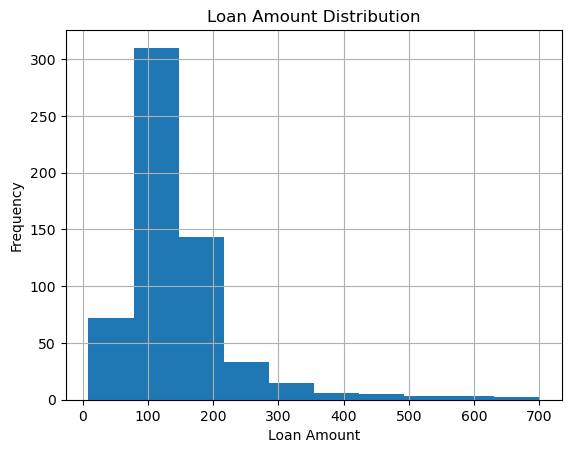

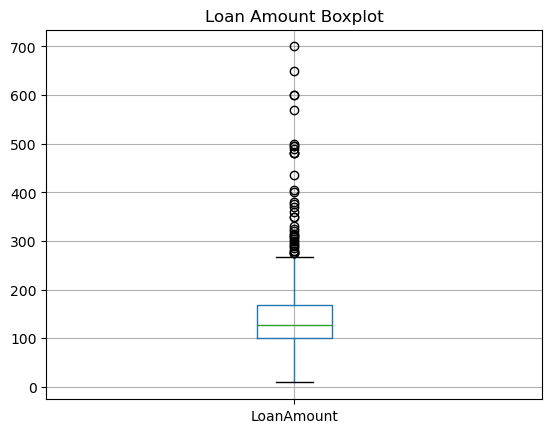

Missing Values: 22


In [9]:
print(df["LoanAmount"].describe())

df["LoanAmount"].hist()
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

df.boxplot(column="LoanAmount")
plt.title("Loan Amount Boxplot")
plt.show()

print("Missing Values:", df["LoanAmount"].isna().sum())

## LOAN AMOUNT TERM
- There are 14 missing values out of 614
- Most loans have a repayment term of 360 months.
- The distribution is heavily concentrated around 360 months.
- The boxplot shows relatively little variation compared to the income-related variables.

count    600.00000
mean     342.00000
std       65.12041
min       12.00000
25%      360.00000
50%      360.00000
75%      360.00000
max      480.00000
Name: Loan_Amount_Term, dtype: float64


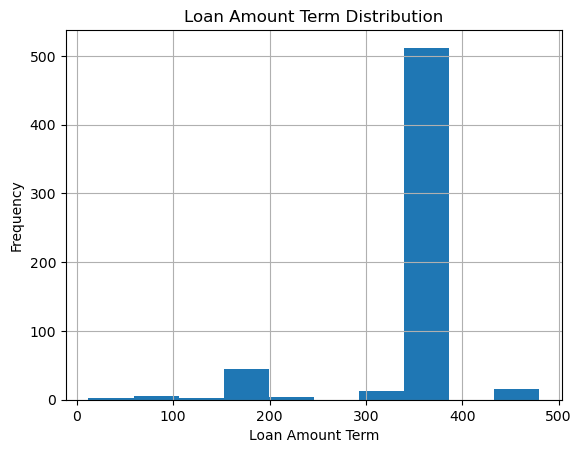

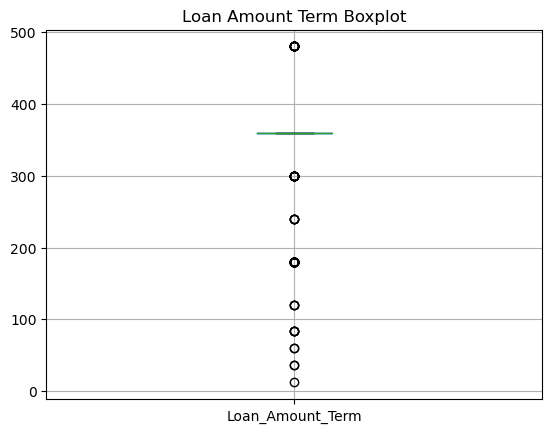

Missing Values: 14


In [10]:
print(df["Loan_Amount_Term"].describe())

df["Loan_Amount_Term"].hist()
plt.title("Loan Amount Term Distribution")
plt.xlabel("Loan Amount Term")
plt.ylabel("Frequency")
plt.show()

df.boxplot(column="Loan_Amount_Term")
plt.title("Loan Amount Term Boxplot")
plt.show()

print("Missing Values:", df["Loan_Amount_Term"].isna().sum())

## CREDIT HISTORY

- Credit History is a binary feature taking values 0 and 1.
- Most applicants have a credit history of 1.
- There are 50 missing values.
- The standard deviation is low because the values are limited to two categories.
- The distribution is highly imbalanced, with many more applicants having a credit history of 1 than 0.

count    564.000000
mean       0.842199
std        0.364878
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: Credit_History, dtype: float64
Credit_History
1.0    475
0.0     89
Name: count, dtype: int64


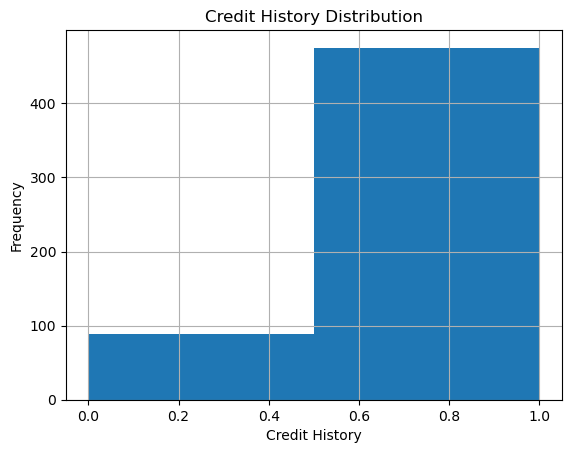

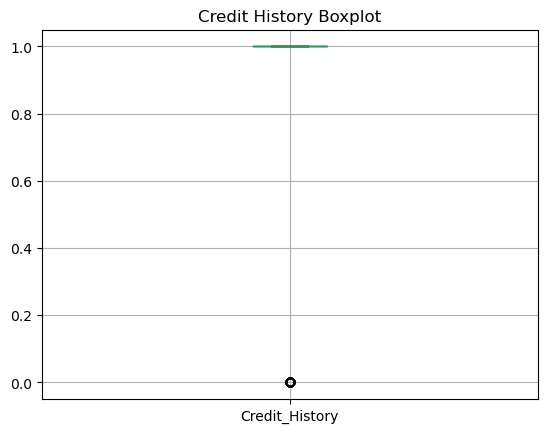

Missing Values: 50


In [11]:
print(df["Credit_History"].describe())

print(df["Credit_History"].value_counts())

df["Credit_History"].hist(bins=2)
plt.title("Credit History Distribution")
plt.xlabel("Credit History")
plt.ylabel("Frequency")
plt.show()

df.boxplot(column="Credit_History")
plt.title("Credit History Boxplot")
plt.show()

print("Missing Values:", df["Credit_History"].isna().sum())

### GENDER

- The majority of loan applicants are male.
- Female applicants make up a smaller proportion of the dataset.
- There are 13 missing values in the Gender column.

Gender
Male      489
Female    112
Name: count, dtype: int64
Gender
Male      81.364393
Female    18.635607
Name: proportion, dtype: float64
Missing Values: 13


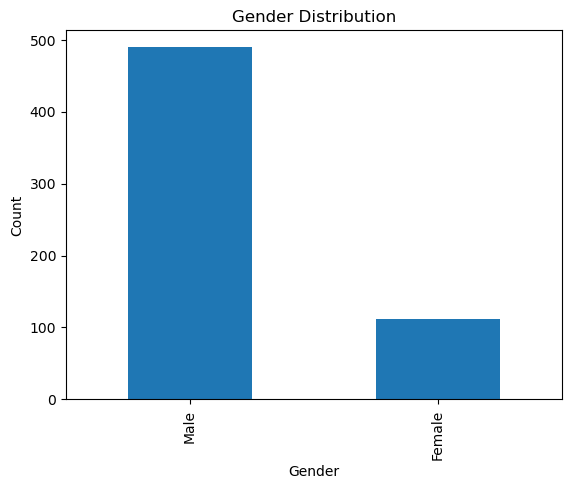

In [12]:
print(df["Gender"].value_counts())
print(df["Gender"].value_counts(normalize=True)*100)

print("Missing Values:", df["Gender"].isna().sum())

df["Gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

### MARRIED

- Most applicants are married.
- Unmarried applicants form a smaller proportion.
- There are 3 missing values.

Married
Yes    398
No     213
Name: count, dtype: int64
Married
Yes    65.139116
No     34.860884
Name: proportion, dtype: float64
Missing Values: 3


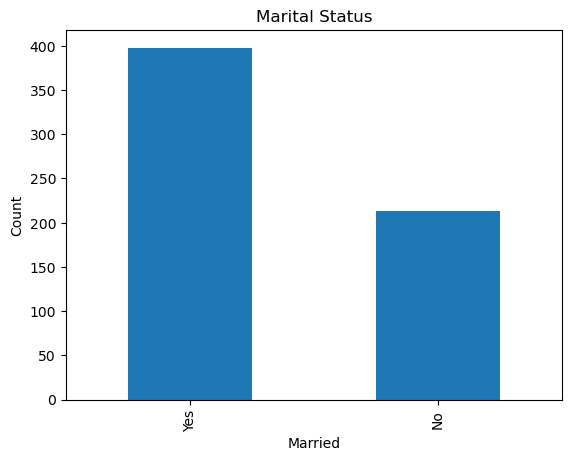

In [13]:
print(df["Married"].value_counts())
print(df["Married"].value_counts(normalize=True)*100)

print("Missing Values:", df["Married"].isna().sum())

df["Married"].value_counts().plot(kind="bar")

plt.title("Marital Status")
plt.xlabel("Married")
plt.ylabel("Count")

plt.show()

### DEPENDENTS

- Applicants with no dependents form the largest group.
- The number of applicants decreases as the number of dependents increases.
- There are 15 missing values.

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64
Dependents
0     57.595993
1     17.028381
2     16.861436
3+     8.514190
Name: proportion, dtype: float64
Missing Values: 15


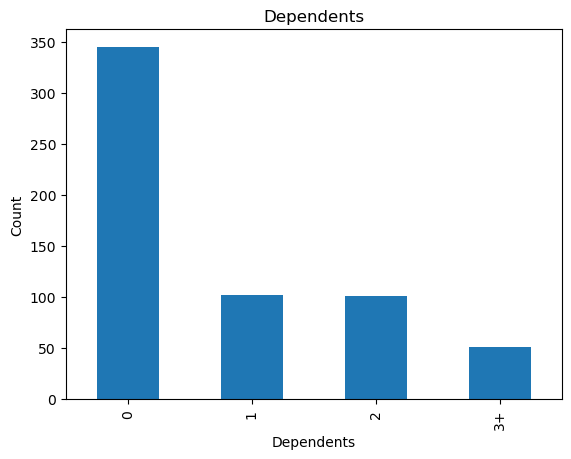

In [14]:
print(df["Dependents"].value_counts())
print(df["Dependents"].value_counts(normalize=True)*100)

print("Missing Values:", df["Dependents"].isna().sum())

df["Dependents"].value_counts().plot(kind="bar")

plt.title("Dependents")
plt.xlabel("Dependents")
plt.ylabel("Count")

plt.show()

### EDUCATION

- Most applicants are graduates.
- Non-graduates represent a smaller portion of the dataset.
- No missing values are present.

Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64
Education
Graduate        78.175896
Not Graduate    21.824104
Name: proportion, dtype: float64
Missing Values: 0


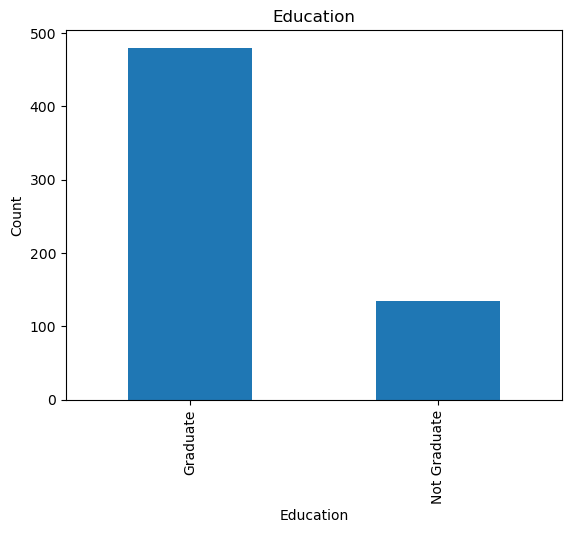

In [15]:
print(df["Education"].value_counts())
print(df["Education"].value_counts(normalize=True)*100)

print("Missing Values:", df["Education"].isna().sum())

df["Education"].value_counts().plot(kind="bar")

plt.title("Education")
plt.xlabel("Education")
plt.ylabel("Count")

plt.show()

### SELF EMPLOYED

- The majority of applicants are not self-employed.
- Self-employed applicants are comparatively fewer.
- There are 32 missing values.

Self_Employed
No     500
Yes     82
Name: count, dtype: int64
Self_Employed
No     85.910653
Yes    14.089347
Name: proportion, dtype: float64
Missing Values: 32


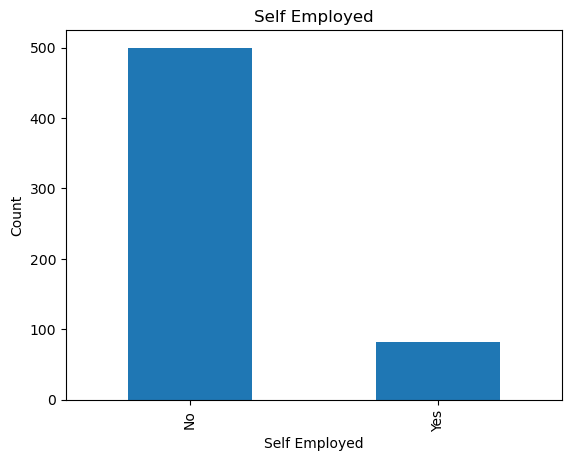

In [16]:
print(df["Self_Employed"].value_counts())
print(df["Self_Employed"].value_counts(normalize=True)*100)

print("Missing Values:", df["Self_Employed"].isna().sum())

df["Self_Employed"].value_counts().plot(kind="bar")

plt.title("Self Employed")
plt.xlabel("Self Employed")
plt.ylabel("Count")

plt.show()

### PROPERTY AREA

- Applicants are fairly evenly distributed across Urban, Rural, and Semiurban areas.
- Semiurban has the highest number of applicants.
- There are no missing values.

Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64
Property_Area
Semiurban    37.947883
Urban        32.899023
Rural        29.153094
Name: proportion, dtype: float64
Missing Values: 0


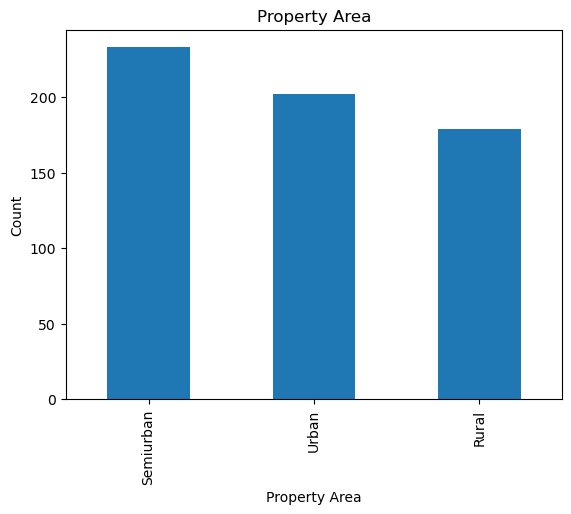

In [17]:
print(df["Property_Area"].value_counts())
print(df["Property_Area"].value_counts(normalize=True)*100)

print("Missing Values:", df["Property_Area"].isna().sum())

df["Property_Area"].value_counts().plot(kind="bar")

plt.title("Property Area")
plt.xlabel("Property Area")
plt.ylabel("Count")

plt.show()

### LOAN STATUS

- Most loan applications have been approved.
- The dataset contains both approved and rejected applications, making it suitable for classification.
- There are no missing values.
- This is the target variable that our model will predict.

Loan_Status
Y    422
N    192
Name: count, dtype: int64
Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64
Missing Values: 0


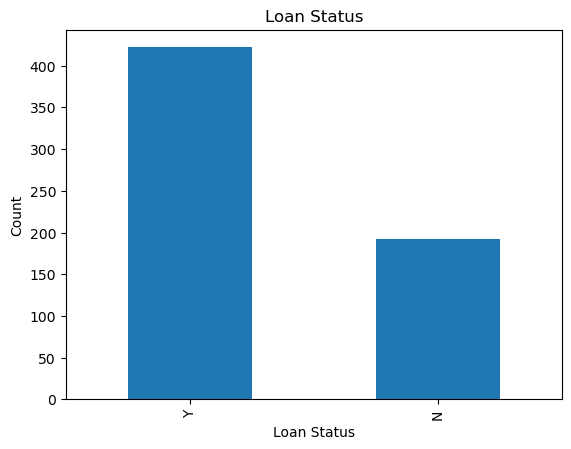

In [18]:
print(df["Loan_Status"].value_counts())
print(df["Loan_Status"].value_counts(normalize=True)*100)

print("Missing Values:", df["Loan_Status"].isna().sum())

df["Loan_Status"].value_counts().plot(kind="bar")

plt.title("Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

## UNDERSTANDING THE FACTORS AFFECTING LOAN STATUS

## GENDER VS LOAN STATUS
- Male applicants have a slightly higher loan approval rate than female applicants.
- The difference in approval rates is small, so gender does not appear to have a strong influence on loan approval.
- Gender may contribute to the model, but it is unlikely to be one of the most important predictors.

Loan_Status    N    Y
Gender               
Female        37   75
Male         150  339

Percentage:
Loan_Status          N          Y
Gender                           
Female       33.035714  66.964286
Male         30.674847  69.325153


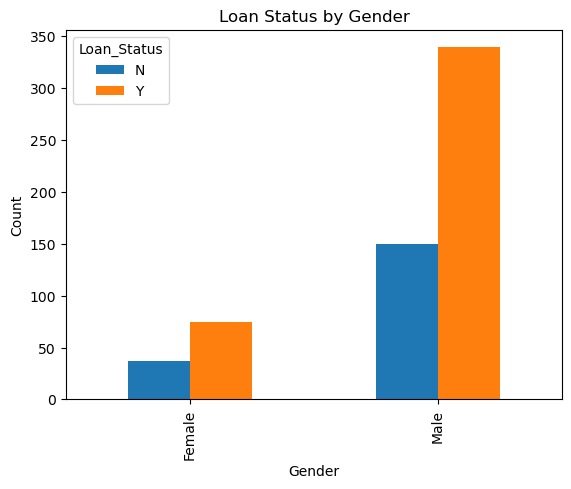

In [19]:
print(pd.crosstab(df["Gender"], df["Loan_Status"]))

print("\nPercentage:")

print(
    pd.crosstab(
        df["Gender"],
        df["Loan_Status"],
        normalize="index"
    ) * 100
)

pd.crosstab(df["Gender"], df["Loan_Status"]).plot(kind="bar")

plt.title("Loan Status by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

## MARRIED VS LOAN STATUS
- Married applicants have a higher loan approval rate (≈71.6%) than unmarried applicants (≈62.9%).
- Marital status appears to have a moderate relationship with loan approval.
- This feature may provide useful information for the prediction model.

Loan_Status    N    Y
Married              
No            79  134
Yes          113  285

Percentage:
Loan_Status          N          Y
Married                          
No           37.089202  62.910798
Yes          28.391960  71.608040


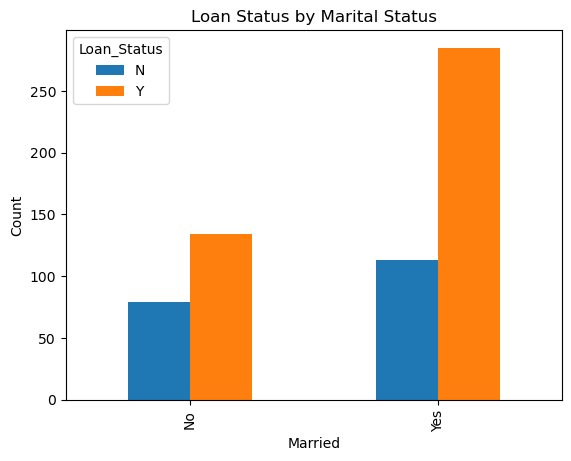

In [20]:
print(pd.crosstab(df["Married"], df["Loan_Status"]))

print("\nPercentage:")

print(
    pd.crosstab(
        df["Married"],
        df["Loan_Status"],
        normalize="index"
    ) * 100
)

pd.crosstab(df["Married"], df["Loan_Status"]).plot(kind="bar")

plt.title("Loan Status by Marital Status")
plt.xlabel("Married")
plt.ylabel("Count")
plt.show()

## DEPENDENT VS LOAN STATUS
- Applicants with 2 dependents have the highest loan approval rate (≈75%).
- Applicants with 1 and 3+ dependents have similar approval rates (≈65%).
- Applicants with 0 dependents have a slightly lower approval rate (≈69%).
- The relationship is present but not very strong, so this feature may have moderate predictive value.

Loan_Status    N    Y
Dependents           
0            107  238
1             36   66
2             25   76
3+            18   33

Percentage:
Loan_Status          N          Y
Dependents                       
0            31.014493  68.985507
1            35.294118  64.705882
2            24.752475  75.247525
3+           35.294118  64.705882


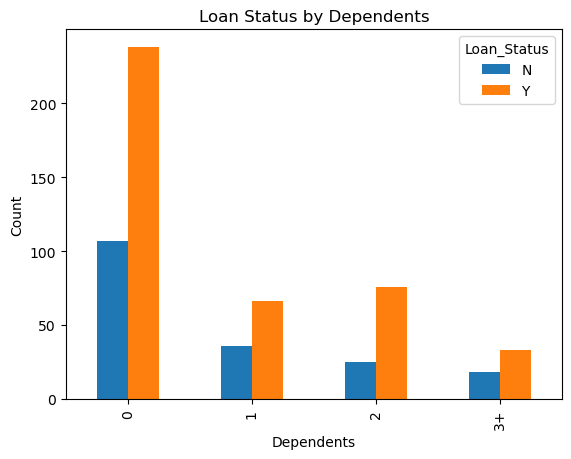

In [21]:
print(pd.crosstab(df["Dependents"], df["Loan_Status"]))

print("\nPercentage:")

print(
    pd.crosstab(
        df["Dependents"],
        df["Loan_Status"],
        normalize="index"
    ) * 100
)

pd.crosstab(df["Dependents"], df["Loan_Status"]).plot(kind="bar")

plt.title("Loan Status by Dependents")
plt.xlabel("Dependents")
plt.ylabel("Count")
plt.show()

## EDUCATION VS LOAN STATUS
- Graduates have a higher loan approval rate (≈70.8%) than non-graduates (≈61.2%).
- Education appears to influence loan approval to some extent.
- This feature may be useful for predicting loan approval.

Loan_Status     N    Y
Education             
Graduate      140  340
Not Graduate   52   82

Percentage:
Loan_Status           N          Y
Education                         
Graduate      29.166667  70.833333
Not Graduate  38.805970  61.194030


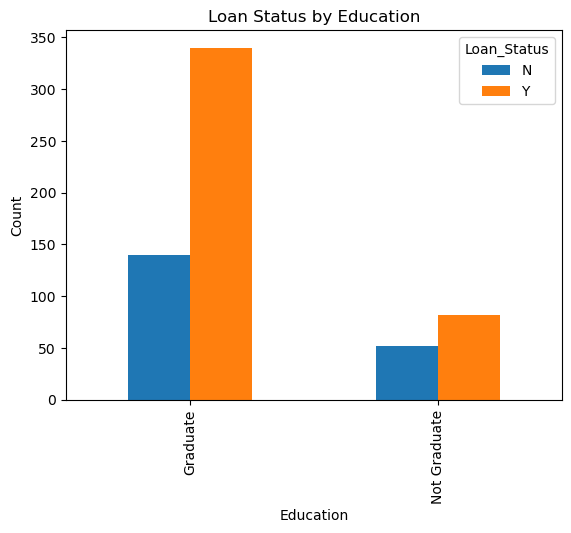

In [22]:
print(pd.crosstab(df["Education"], df["Loan_Status"]))

print("\nPercentage:")

print(
    pd.crosstab(
        df["Education"],
        df["Loan_Status"],
        normalize="index"
    ) * 100
)

pd.crosstab(df["Education"], df["Loan_Status"]).plot(kind="bar")

plt.title("Loan Status by Education")
plt.xlabel("Education")
plt.ylabel("Count")
plt.show()

## SELF EMPLOYED VS LOAN STATUS

- Self-employed and non-self-employed applicants have almost identical approval rates (≈68%).
- Self-employment status does not appear to have a strong relationship with loan approval.
- This feature is likely to have limited importance in the prediction model.

Loan_Status      N    Y
Self_Employed          
No             157  343
Yes             26   56

Percentage:
Loan_Status            N          Y
Self_Employed                      
No             31.400000  68.600000
Yes            31.707317  68.292683


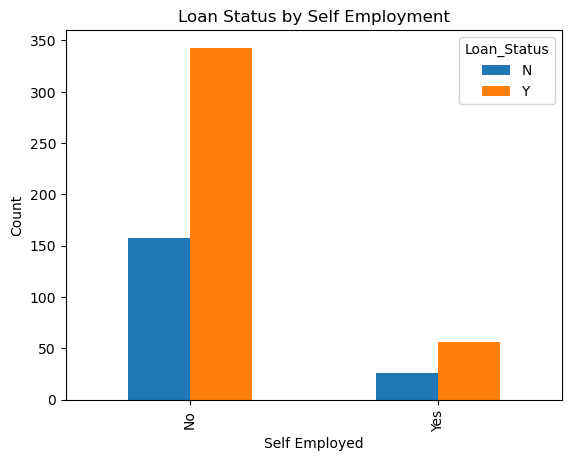

In [23]:
print(pd.crosstab(df["Self_Employed"], df["Loan_Status"]))

print("\nPercentage:")

print(
    pd.crosstab(
        df["Self_Employed"],
        df["Loan_Status"],
        normalize="index"
    ) * 100
)

pd.crosstab(df["Self_Employed"], df["Loan_Status"]).plot(kind="bar")

plt.title("Loan Status by Self Employment")
plt.xlabel("Self Employed")
plt.ylabel("Count")
plt.show()

## PROPERTY AREA VS LOAN STATUS

- Applicants from Semiurban areas have the highest approval rate (≈76.8%).
- Urban applicants have a moderate approval rate (≈65.8%).
- Rural applicants have the lowest approval rate (≈61.5%).
- Property area appears to have a noticeable relationship with loan approval and may be an important predictor.

Loan_Status     N    Y
Property_Area         
Rural          69  110
Semiurban      54  179
Urban          69  133

Percentage:
Loan_Status            N          Y
Property_Area                      
Rural          38.547486  61.452514
Semiurban      23.175966  76.824034
Urban          34.158416  65.841584


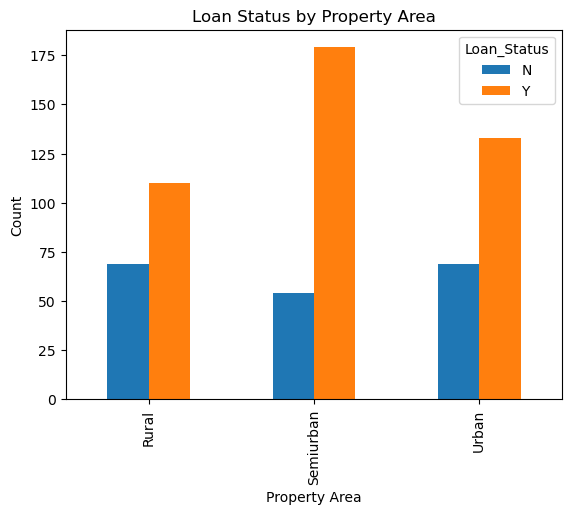

In [24]:
print(pd.crosstab(df["Property_Area"], df["Loan_Status"]))

print("\nPercentage:")

print(
    pd.crosstab(
        df["Property_Area"],
        df["Loan_Status"],
        normalize="index"
    ) * 100
)

pd.crosstab(df["Property_Area"], df["Loan_Status"]).plot(kind="bar")

plt.title("Loan Status by Property Area")
plt.xlabel("Property Area")
plt.ylabel("Count")
plt.show()

## CREDIT HISTORY VS LOAN STATUS
- Applicants with a credit history of 1 have a very high approval rate (≈79.6%).
- Applicants with a credit history of 0 have a very low approval rate (≈7.9%).
- Credit history shows the strongest relationship with loan approval among all categorical features analyzed.
- This is likely to be one of the most important predictors in the machine learning model.

Loan_Status      N    Y
Credit_History         
0.0             82    7
1.0             97  378

Percentage:
Loan_Status             N          Y
Credit_History                      
0.0             92.134831   7.865169
1.0             20.421053  79.578947


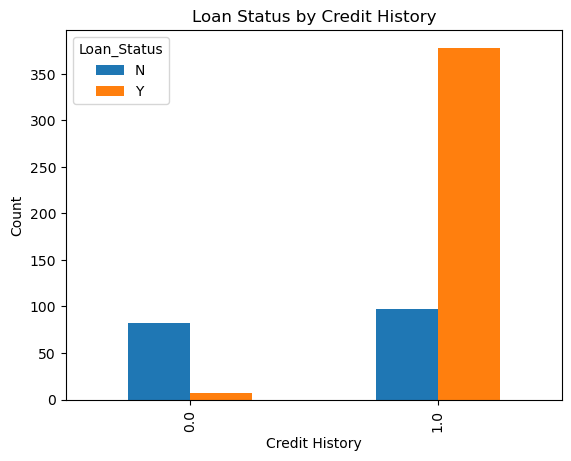

In [25]:
print(pd.crosstab(df["Credit_History"], df["Loan_Status"]))

print("\nPercentage:")

print(
    pd.crosstab(
        df["Credit_History"],
        df["Loan_Status"],
        normalize="index"
    ) * 100
)

pd.crosstab(df["Credit_History"], df["Loan_Status"]).plot(kind="bar")

plt.title("Loan Status by Credit History")
plt.xlabel("Credit History")
plt.ylabel("Count")
plt.show()

## APPLICANT INCOME VS LOAN STATUS
- The median applicant income is very similar for approved (Y) and rejected (N) loans.
- The average income is slightly higher for rejected applicants (₹5446) than approved applicants (₹5384), but the difference is small.
- Both groups have many high-income outliers, indicating a right-skewed distribution.
- Applicant income alone does not appear to strongly distinguish approved from rejected loans.

             count         mean          std    min     25%     50%      75%  \
Loan_Status                                                                    
N            192.0  5446.078125  6819.558528  150.0  2885.0  3833.5  5861.25   
Y            422.0  5384.068720  5765.441615  210.0  2877.5  3812.5  5771.50   

                 max  
Loan_Status           
N            81000.0  
Y            63337.0  


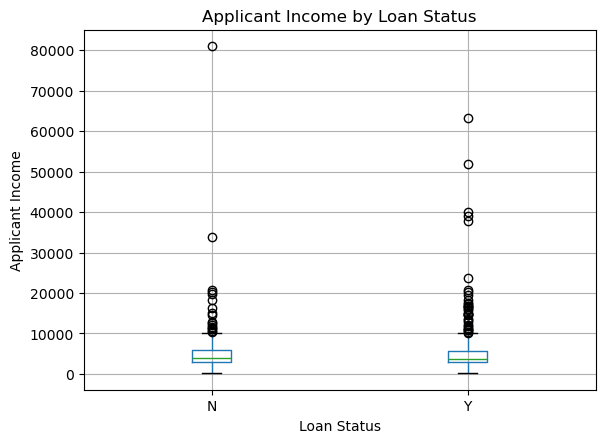

In [26]:
print(df.groupby("Loan_Status")["ApplicantIncome"].describe())

df.boxplot(column="ApplicantIncome", by="Loan_Status")
plt.title("Applicant Income by Loan Status")
plt.suptitle("")
plt.xlabel("Loan Status")
plt.ylabel("Applicant Income")
plt.show()

## COAPPLICANT INCOME VS LOAN STATUS
- The median coapplicant income is slightly higher for approved loans than rejected loans.
- Both groups contain many applicants with zero coapplicant income, suggesting many people applied without a coapplicant.
- Several extreme outliers are present, especially among rejected applications.
- Coapplicant income by itself does not show a strong separation between approved and rejected loans.

             count         mean          std  min  25%     50%      75%  \
Loan_Status                                                               
N            192.0  1877.807292  4384.060103  0.0  0.0   268.0  2273.75   
Y            422.0  1504.516398  1924.754855  0.0  0.0  1239.5  2297.25   

                 max  
Loan_Status           
N            41667.0  
Y            20000.0  


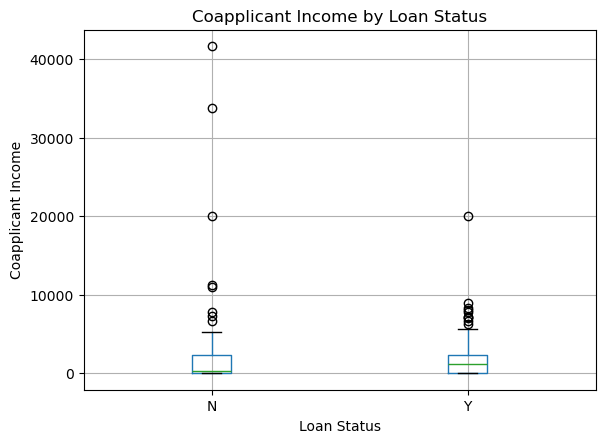

In [27]:
print(df.groupby("Loan_Status")["CoapplicantIncome"].describe())

df.boxplot(column="CoapplicantIncome", by="Loan_Status")
plt.title("Coapplicant Income by Loan Status")
plt.suptitle("")
plt.xlabel("Loan Status")
plt.ylabel("Coapplicant Income")
plt.show()

## LOAN AMOUNT VS LOAN STATUS

- The median loan amount is very similar for both approved and rejected applications.
- Both groups show a wide spread in loan amounts with several high-value outliers.
- Approved loans contain slightly higher maximum loan amounts, but the overall distributions overlap considerably.
- Loan amount alone does not appear to be a strong predictor of loan approval.

             count        mean        std   min    25%    50%    75%    max
Loan_Status                                                                
N            181.0  151.220994  85.862783   9.0  100.0  129.0  176.0  570.0
Y            411.0  144.294404  85.484607  17.0  100.0  126.0  161.0  700.0


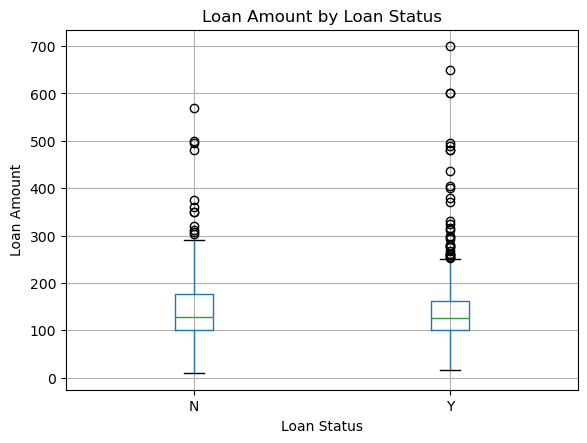

In [28]:
print(df.groupby("Loan_Status")["LoanAmount"].describe())

df.boxplot(column="LoanAmount", by="Loan_Status")
plt.title("Loan Amount by Loan Status")
plt.suptitle("")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")
plt.show()

## LOAN AMOUNT TERM VS LOAN STATUS

- The median loan term is 360 months for both approved and rejected loans.
- Most loans are concentrated around 360 months, indicating that this is the standard repayment period.
- Both groups have a few shorter and longer loan terms, which appear as outliers.
- Loan amount term shows very little difference between approved and rejected loans and is unlikely to be a highly influential feature on its own.

             count        mean        std   min    25%    50%    75%    max
Loan_Status                                                                
N            186.0  344.064516  69.238921  36.0  360.0  360.0  360.0  480.0
Y            414.0  341.072464  63.247770  12.0  360.0  360.0  360.0  480.0


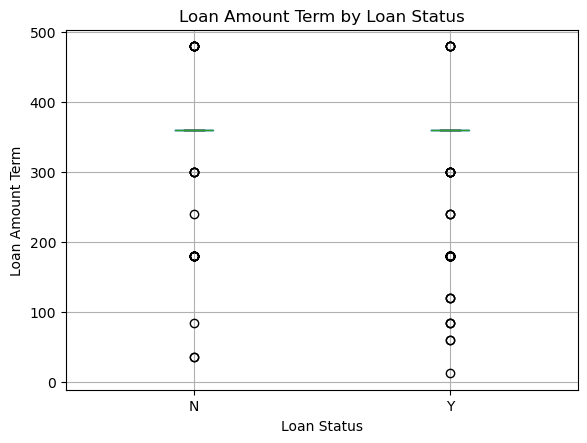

In [29]:
print(df.groupby("Loan_Status")["Loan_Amount_Term"].describe())

df.boxplot(column="Loan_Amount_Term", by="Loan_Status")
plt.title("Loan Amount Term by Loan Status")
plt.suptitle("")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount Term")
plt.show()

## CORRELATION MATRIX

In [30]:
numeric = df.select_dtypes(include="number")

corr = numeric.corr()

print(corr)

                   ApplicantIncome  CoapplicantIncome  LoanAmount  \
ApplicantIncome           1.000000          -0.116605    0.570909   
CoapplicantIncome        -0.116605           1.000000    0.188619   
LoanAmount                0.570909           0.188619    1.000000   
Loan_Amount_Term         -0.045306          -0.059878    0.039447   
Credit_History           -0.014715          -0.002056   -0.008433   

                   Loan_Amount_Term  Credit_History  
ApplicantIncome           -0.045306       -0.014715  
CoapplicantIncome         -0.059878       -0.002056  
LoanAmount                 0.039447       -0.008433  
Loan_Amount_Term           1.000000        0.001470  
Credit_History             0.001470        1.000000  


## CORRELATION HEATMAP

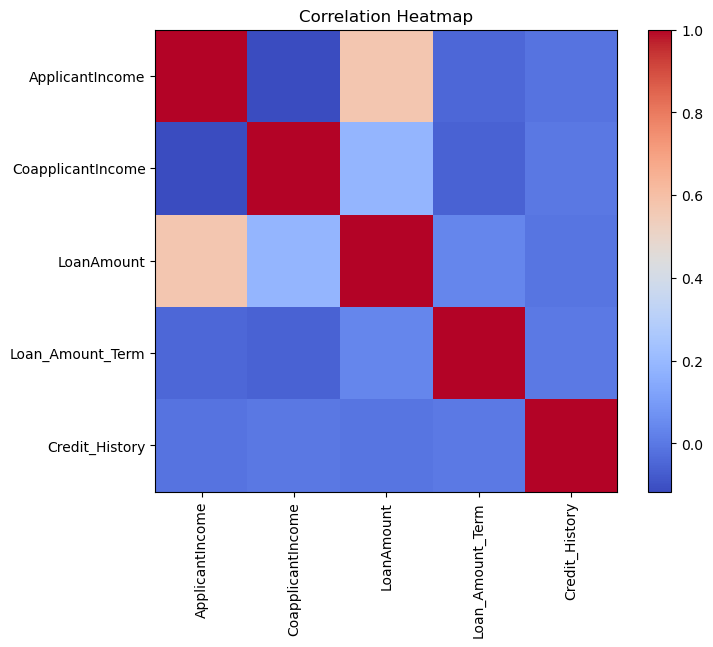

In [31]:
plt.figure(figsize=(8,6))

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.show()

### Total Income

In [32]:
df["TotalIncome"] = df["ApplicantIncome"] + df["CoapplicantIncome"]
df[["ApplicantIncome","CoapplicantIncome","TotalIncome"]].head()

,ApplicantIncome,CoapplicantIncome,TotalIncome
0,5849,0.0,5849.0
1,4583,1508.0,6091.0
2,3000,0.0,3000.0
3,2583,2358.0,4941.0
4,6000,0.0,6000.0


### Income Distribution

count      614.000000
mean      7024.705081
std       6458.663872
min       1442.000000
25%       4166.000000
50%       5416.500000
75%       7521.750000
max      81000.000000
Name: TotalIncome, dtype: float64


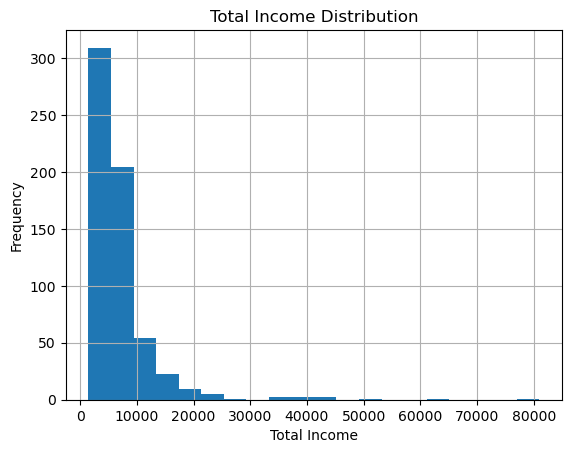

In [33]:
print(df["TotalIncome"].describe())

df["TotalIncome"].hist(bins=20)

plt.title("Total Income Distribution")

plt.xlabel("Total Income")

plt.ylabel("Frequency")

plt.show()

### Total Income vs Loan Status

             count         mean          std     min      25%     50%  \
Loan_Status                                                             
N            192.0  7323.885417  7739.774247  1442.0  4162.75  5289.5   
Y            422.0  6888.585118  5788.062269  1963.0  4188.75  5439.0   

                 75%      max  
Loan_Status                    
N            7570.75  81000.0  
Y            7452.50  63337.0  


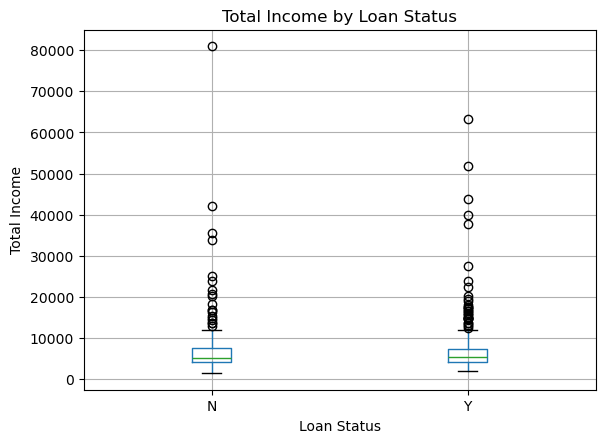

In [34]:
print(df.groupby("Loan_Status")["TotalIncome"].describe())

df.boxplot(column="TotalIncome", by="Loan_Status")

plt.title("Total Income by Loan Status")

plt.suptitle("")

plt.xlabel("Loan Status")

plt.ylabel("Total Income")

plt.show()

## MISSING VALUE TREATMENT

In [35]:
# Categorical columns
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

df["Married"] = df["Married"].fillna(df["Married"].mode()[0])

df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])

df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])

# Numerical columns
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())

df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median())

# Credit History (simple approach)
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

In [36]:
df.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
TotalIncome          0
dtype: int64

### LABEL ENCODING

In [37]:
df["Gender"] = df["Gender"].map({"Male":1,"Female":0})

In [38]:
df["Married"] = df["Married"].map({"Yes":1,"No":0})

In [39]:
df["Education"] = df["Education"].map({"Graduate":1,"Not Graduate":0})

In [40]:
df["Loan_Status"] = df["Loan_Status"].map({"Y":1,"N":0})

In [41]:
df = pd.get_dummies(df, columns=["Property_Area"], dtype=int)

In [42]:
df["Dependents"] = df["Dependents"].replace("3+", 3)
df["Dependents"] = pd.to_numeric(df["Dependents"])

In [43]:
df["Self_Employed"] = df["Self_Employed"].map({"Yes": 1, "No": 0})

## TRAIN TEST SPLIT

In [57]:
X = df.drop("Loan_Status", axis=1)
X = X.drop("Loan_ID", axis=1)

y = df["Loan_Status"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scale_cols = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "TotalIncome"
]

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

In [62]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [63]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

0.7886178861788617


In [64]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[18 25]
 [ 1 79]]


### Observations from the Confusion Matrix
- True Negative (TN) = 18
- False Positive (FP) = 25
- False Negative (FN) = 1
- True Positive (TP) = 79

In [65]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



## Observations from the Classification Report

- The overall model accuracy is **78.86%**, indicating that the model correctly predicts the loan status for most applicants.

- For **Approved Loans (Class 1)**:
  - The model has a **Precision of 0.76**, meaning that when it predicts a loan will be approved, it is correct about **76%** of the time.
  - The **Recall is 0.99**, which indicates that the model successfully identifies **99% of all applicants whose loans should be approved**.
  - The **F1-score of 0.86** shows a strong overall performance for this class.

- For **Rejected Loans (Class 0)**:
  - The model has a **Precision of 0.95**, meaning that when it predicts a loan should be rejected, it is usually correct.
  - However, the **Recall is only 0.42**, indicating that it identifies only **42% of the actual rejected loans**.
  - The **F1-score of 0.58** suggests relatively weaker performance for this class.

- The **Macro Average** is lower than the **Weighted Average**, showing that the model performs much better on one class than the other.

- Since the dataset contains more approved loans than rejected loans, the **Weighted Average** is influenced more by the performance on approved loans.

## Understanding

The Logistic Regression model performs well at identifying applicants who deserve loan approval, correctly classifying nearly all approved cases. However, it struggles to identify applicants who should be rejected, resulting in a relatively high number of false approvals.

For a banking application, this is an important limitation because approving risky applicants can lead to financial losses. While the model demonstrates good overall accuracy, improving the detection of rejected loans (Class 0) would make it more reliable for real-world loan approval systems.

## IMPLEMENTING DECISION TREE

In [68]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [69]:
dt_pred = dt_model.predict(X_test)

In [70]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.7073170731707317


In [71]:
from sklearn.metrics import classification_report

print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.59      0.53      0.56        43
           1       0.76      0.80      0.78        80

    accuracy                           0.71       123
   macro avg       0.68      0.67      0.67       123
weighted avg       0.70      0.71      0.70       123



## Observations from the Decision Tree Classification Report

- The Decision Tree model achieved an overall **accuracy of 70.73%**, which is lower than the Logistic Regression model.

- For **Approved Loans (Class 1)**:
  - The **Precision is 0.76**, meaning that when the model predicts a loan will be approved, it is correct **76%** of the time.
  - The **Recall is 0.80**, indicating that the model correctly identifies **80% of all approved loans**.
  - The **F1-score is 0.78**, showing a reasonably balanced performance for this class.

- For **Rejected Loans (Class 0)**:
  - The **Precision is 0.59**, meaning that when the model predicts a loan rejection, it is correct only **59%** of the time.
  - The **Recall is 0.53**, indicating that it correctly identifies **53% of the actual rejected loans**.
  - The **F1-score is 0.56**, suggesting relatively weak performance for this class.

- The **Macro Average** and **Weighted Average** are both around **0.70**, indicating moderate overall performance across both classes.

## Understanding

The Decision Tree model is able to classify approved loans reasonably well but struggles to accurately identify rejected loan applications. Its performance is more balanced between the two classes than Logistic Regression, but the overall predictive performance is weaker.

Compared to Logistic Regression, the Decision Tree produces more misclassifications, resulting in a lower overall accuracy. This suggests that the default Decision Tree may not be the most suitable model for this dataset without further tuning, such as limiting its depth or adjusting other hyperparameters.

In [72]:
comparison = {
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [accuracy, dt_accuracy]
}

import pandas as pd

pd.DataFrame(comparison)

,Model,Accuracy
0,Logistic Regression,0.788618
1,Decision Tree,0.707317


## Model Comparison

| Model | Accuracy |
|--------|----------|
| Logistic Regression | **78.86%** |
| Decision Tree | **70.73%** |

## Observations

- **Logistic Regression outperformed the Decision Tree**, achieving an accuracy of **78.86%** compared to **70.73%** for the Decision Tree.

- Logistic Regression demonstrated stronger overall predictive performance on the test dataset, correctly classifying a greater proportion of loan applications.

- Although the Decision Tree is capable of learning complex, non-linear relationships, its default configuration appears to generalize less effectively on this dataset.

- Logistic Regression produced a higher F1-score and overall accuracy, making it the better-performing model among the two.

## Conclusion

For this loan prediction dataset, **Logistic Regression is currently the preferred model** because it provides higher predictive accuracy and better overall performance on unseen data.

The Decision Tree can likely be improved through **hyperparameter tuning** (such as adjusting the maximum depth, minimum samples per split, or minimum samples per leaf). These optimizations will be explored before making a final comparison with more advanced models such as Random Forest.

## IMPLEMENTING RANDOM FOREST

In [75]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [76]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)

print(rf_accuracy)

0.7886178861788617


In [77]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

[[20 23]
 [ 3 77]]


In [78]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.87      0.47      0.61        43
           1       0.77      0.96      0.86        80

    accuracy                           0.79       123
   macro avg       0.82      0.71      0.73       123
weighted avg       0.80      0.79      0.77       123



## Observations from the Classification Report

- The Random Forest model achieved an overall accuracy of **78.86%**, matching the Logistic Regression model.
- Class 1 (Loan Approved) has a high recall of **0.96**, meaning the model correctly identifies most approved loans.
- Precision for Class 1 is **0.77**, indicating that most predicted approvals are correct.
- Class 0 (Loan Rejected) has a precision of **0.87**, meaning predicted rejections are usually correct.
- However, the recall for Class 0 is only **0.47**, showing that many rejected loans are still being classified as approved.
- The weighted F1-score of **0.77** indicates balanced overall performance across both classes.

## Understanding the Classification Report

The Random Forest model performs very well in identifying approved loan applications while maintaining a good overall balance between precision and recall.

However, similar to Logistic Regression, it struggles to correctly identify rejected applications, as reflected by the relatively low recall for Class 0.

Although the overall accuracy is high, improving the detection of rejected loans would reduce the financial risk associated with approving potentially risky applicants.

In [79]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.788618
1,Decision Tree,0.707317
2,Random Forest,0.788618


## Model Comparison

- Logistic Regression achieved an accuracy of **78.86%**.
- Decision Tree achieved an accuracy of **70.73%**.
- Random Forest achieved an accuracy of **78.86%**.
- Logistic Regression and Random Forest performed equally well on this dataset.
- Decision Tree produced the lowest accuracy, suggesting that a single tree is less effective than ensemble methods or linear models for this problem.

## Understanding the Model Comparison

Among the three models, Logistic Regression and Random Forest provided the best predictive performance with identical accuracies.

While Decision Tree is easy to interpret, it is more prone to overfitting and therefore produced lower test accuracy.

Since Random Forest combines multiple Decision Trees, it reduces overfitting and offers more robust predictions. In this dataset, however, Logistic Regression performs equally well while remaining simpler and more computationally efficient.

## FEATURE IMPORTANCE FOR RANDOM FOREST

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

                    Feature  Importance
9            Credit_History    0.245840
10              TotalIncome    0.168820
5           ApplicantIncome    0.140641
7                LoanAmount    0.138264
6         CoapplicantIncome    0.086107
8          Loan_Amount_Term    0.048341
2                Dependents    0.042118
1                   Married    0.024337
12  Property_Area_Semiurban    0.022072
3                 Education    0.020474
11      Property_Area_Rural    0.017735
0                    Gender    0.017441
4             Self_Employed    0.015699
13      Property_Area_Urban    0.012111


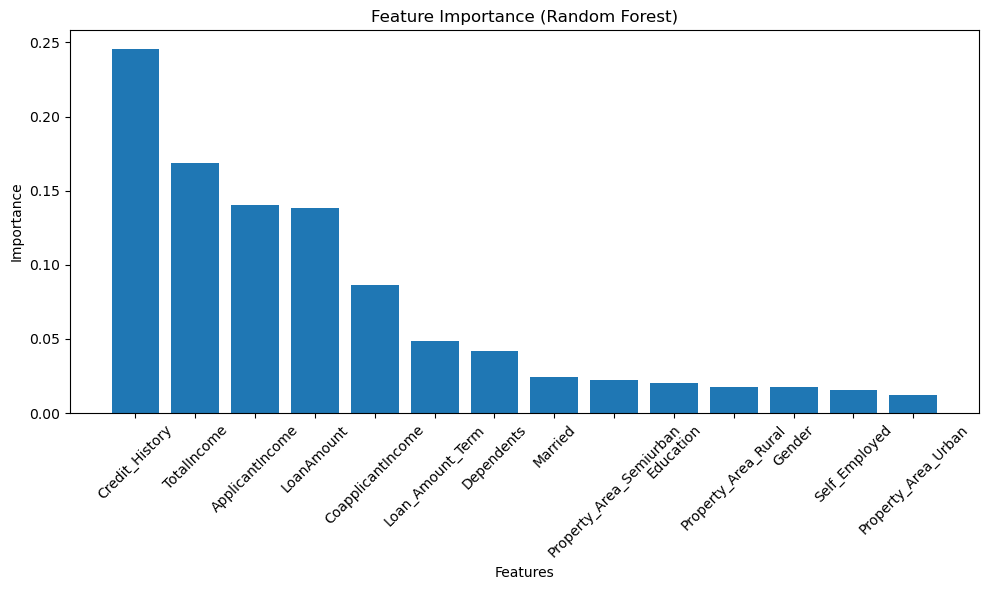

In [81]:
plt.figure(figsize=(10,6))
plt.bar(importance["Feature"], importance["Importance"])
plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

## Observations from Feature Importance

- **Credit_History** is the most important feature with an importance score of approximately **0.246**, indicating that it contributes the most towards predicting loan approval.
- **TotalIncome**, **ApplicantIncome**, and **LoanAmount** are the next most influential features, suggesting that an applicant's financial capacity plays a major role in the model's decisions.
- **CoapplicantIncome** also contributes to the prediction but has a lower importance than the applicant's own income.
- Features such as **Gender**, **Education**, **Self_Employed**, and **Property_Area** have relatively low importance scores, indicating they contribute much less to the model's predictions.
- Overall, financial variables and credit history dominate the prediction process, while demographic features have comparatively smaller influence.

## Understanding Feature Importance

Feature importance measures how much each feature contributes to reducing uncertainty while building the Random Forest model.

The results show that the model primarily relies on an applicant's **credit history** and **financial information** when predicting whether a loan should be approved.

Features with higher importance are used more frequently by the decision trees to create useful splits, whereas features with very low importance have little impact on the final prediction.

These importance values help us understand the model's decision-making process and identify which variables are most influential in predicting loan approval.

## ROC AUC CURVE

In [82]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]


In [84]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

print("AUC:", auc)

AUC: 0.7406976744186047


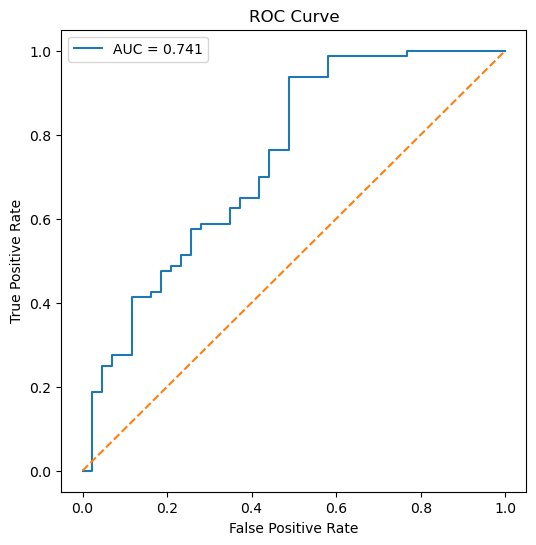

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

## Observations

- The ROC curve lies above the diagonal reference line, indicating that the model performs better than random guessing.
- The model achieved an AUC score of **0.741**, suggesting a moderate ability to distinguish between approved and rejected loan applications.
- Although the model demonstrates acceptable predictive performance, it is not close to the ideal AUC value of 1.0, indicating scope for further improvement.

## Understanding

The Receiver Operating Characteristic (ROC) Curve evaluates the model's performance across all possible classification thresholds by plotting the True Positive Rate against the False Positive Rate.

The Area Under the Curve (AUC) summarizes this performance into a single value between 0 and 1.

- AUC = 0.5 indicates random predictions.
- AUC between 0.7 and 0.8 indicates acceptable discrimination.
- AUC above 0.8 indicates good discrimination.
- AUC close to 1.0 represents an excellent classifier.

The obtained AUC score of **0.741** indicates that the model has a satisfactory ability to distinguish between approved and rejected loan applicants, though additional feature engineering or more advanced models could further improve its performance.

# Conclusion

In this project, an end-to-end machine learning pipeline was developed to predict whether a loan application would be approved based on applicant details.

The project involved:

- Performing Exploratory Data Analysis (EDA) to understand the dataset.
- Handling missing values appropriately.
- Creating a new feature (`TotalIncome`) to better represent the applicant's financial capacity.
- Encoding categorical variables and scaling numerical features.
- Training multiple machine learning models.
- Evaluating model performance using Accuracy, Confusion Matrix, Classification Report, ROC Curve, AUC Score, and Feature Importance.

## Model Comparison

| Model | Accuracy |
|--------|----------|
| Logistic Regression | **78.86%** |
| Random Forest | **78.86%** |
| Decision Tree | **70.73%** |

Both Logistic Regression and Random Forest achieved the highest accuracy of approximately **78.9%**, while Decision Tree performed comparatively worse.

Feature importance analysis showed that **Credit History** was the strongest predictor of loan approval, followed by **Total Income**, **Applicant Income**, and **Loan Amount**.

Although the models achieved reasonable predictive performance, they are not sufficiently accurate for real-world banking applications where incorrect approvals or rejections can have significant financial consequences.

Future improvements could include:

- Hyperparameter tuning
- Cross-validation
- Gradient Boosting models such as XGBoost or LightGBM
- Better feature engineering
- Handling class imbalance
- Using larger and more representative datasets

Overall, this project demonstrates the complete machine learning workflow, from data preprocessing and exploratory analysis to model building and evaluation.